# First method, photonic qnn

### I° Photonic QNN overview

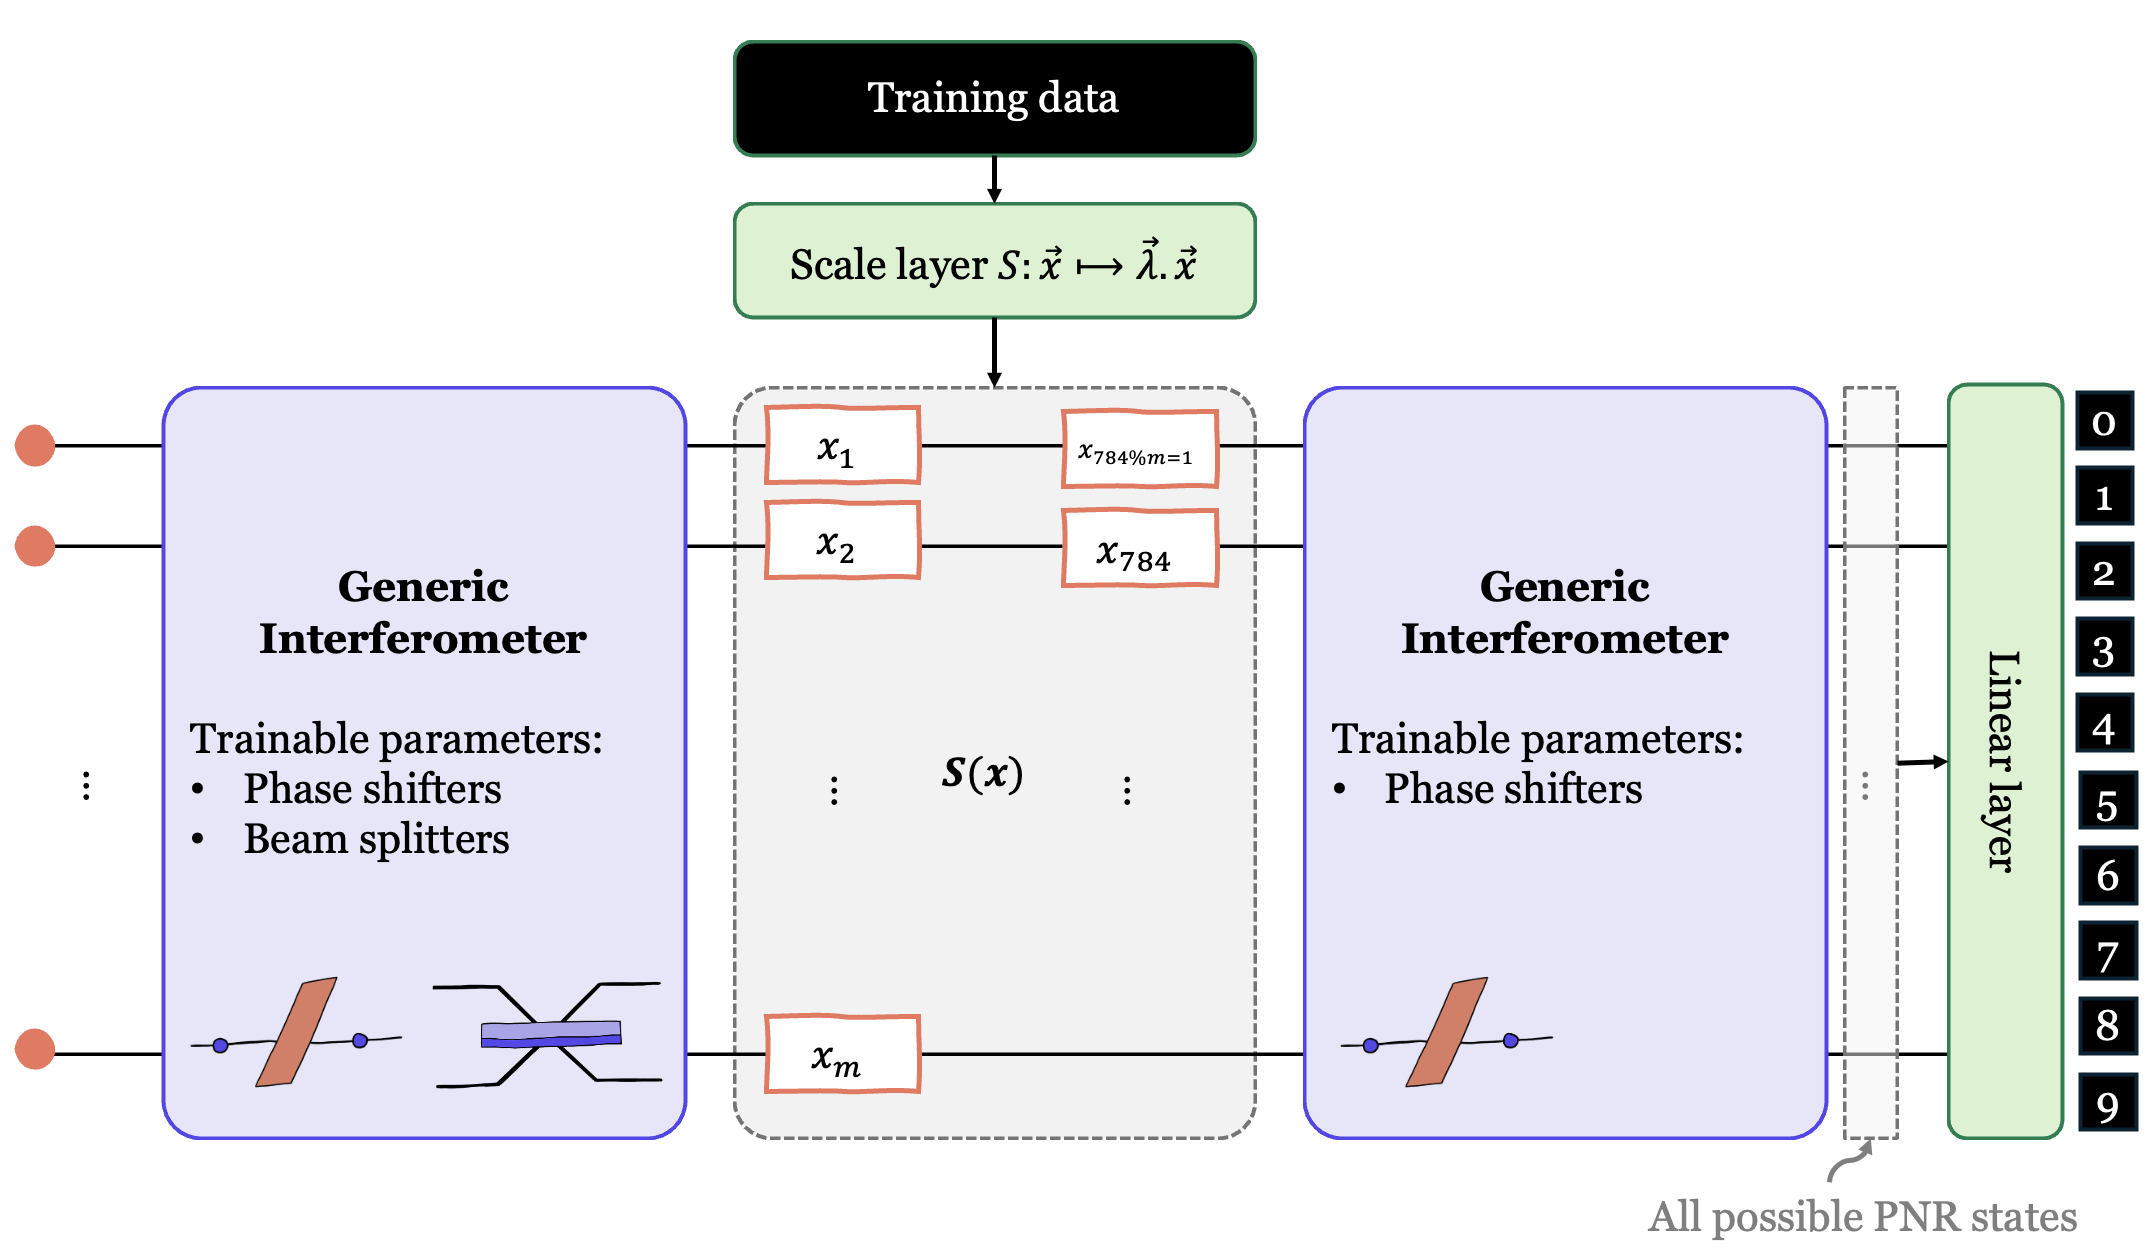

that's what the `create_quantum_circuit` function's do. we initialise a first generic interferometer, fully trainable, then an encoding layer not trainable, and lastly an interferometer which only phase shifters are trainable.

the trainable interferometer may need to rescale the input. that's why we have to construct the `ScaleLayer` class.

In [8]:
import math
import torch
import torch.nn as nn
import perceval as pcvl
from merlin import QuantumLayer
from merlin.measurement.strategies import MeasurementStrategy

###############################
## Build the quantum circuit ##
###############################

INPUT_SIZE = 32

def create_quantum_circuit(m, size=40, frequency=1):
    """Create quantum circuit with specified number of modes"""
    # first trainable generic interferometer
    wl = pcvl.GenericInterferometer(m,
                                    lambda i: pcvl.BS(theta=pcvl.P(f"bs_1_{i}")) // pcvl.PS(pcvl.P(f"phase_1_{i}")) // \
                                              pcvl.BS(theta=pcvl.P(f"bs_2_{i}")) // pcvl.PS(pcvl.P(f"phase_2_{i}")),
                                    shape=pcvl.InterferometerShape.RECTANGLE)
    

    c = pcvl.Circuit(m)
    c.add(0, wl, merge=True)

    # f repetition of {encoding layers with input data in phase shifters; trainable generic interferometer}
    for f in range(frequency):
        c_var = pcvl.Circuit(m)
        for i in range(size):
            px = pcvl.P(f"px-{f}-{i + 1}")
            c_var.add(i % m, pcvl.PS(px))
            
        c.add(0, c_var, merge=True)
        
        wr = pcvl.GenericInterferometer(m,
                                        lambda i: pcvl.BS() // pcvl.PS(pcvl.P(f"phase_3_{i}")) // \
                                                  pcvl.BS() // pcvl.PS(pcvl.P(f"phase_4_{i}")),
                                        shape=pcvl.InterferometerShape.RECTANGLE)
        c.add(0, wr, merge=True)

    return c


class ScaleLayer(nn.Module):
    def __init__(self, dim, scale_type = "learned"):
        super(ScaleLayer, self).__init__()
        # Create a single learnable parameter (initialized to 1.0 by default)
        # Caution: MerLin already mutltiplies by pi
        if scale_type == "learned":
            self.scale = nn.Parameter(torch.rand(dim))
        elif scale_type == "2pi":
            self.scale = torch.full((dim,), 2)
        elif scale_type == "pi":
            self.scale = torch.full((dim,), 1)
        elif scale_type == "1":
            self.scale = torch.full((dim,), 1)
        #print(f"SELF.SCALE: {self.scale.shape}")

    def forward(self, x):
        # Element-wise multiplication of each input element by the learned scale
        return x * self.scale

After the scale layer class construction, we can construct the core model, that we will use to make our classification.
we will use perceval to make the circuit, and package it into merlin's `QuantumLayer` class.

In [9]:
class QLayer(nn.Module):
    def __init__(self, nb_photons, nb_modes, dim, scale_type="learned"):
        super().__init__() 
        self.nb_modes = nb_modes
        self.nb_photons = nb_photons     
        self.scaler = ScaleLayer(dim, scale_type)

        circuit = create_quantum_circuit(m=nb_modes, size=dim, frequency=1)

        input_state = [(i + 1) % 2 for i in range(nb_modes)]

        self.layer = QuantumLayer(
        input_size=dim,
        circuit=circuit,
        input_state=input_state,
        measurement_strategy=MeasurementStrategy.probs(),
        input_parameters=["px"],
        trainable_parameters=["bs", "phase"], 
        )
    def forward(self, x):
        x = self.scaler(x)
        x = self.layer(x) 
        
        return x

We can set the seed to reproduce the results.

In [10]:
def set_seed(seed=42):
    """
    Set the random seed for reproducibility across different libraries.

    Args:
        seed (int): Seed value to use. Default is 42.
    """
    # Set Python's random seed
    random.seed(seed)

    # Set NumPy's random seed
    np.random.seed(seed)

    # Set PyTorch's random seeds for both CPU and CUDA
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    # Additional settings for complete reproducibility
    # Note: This can affect performance
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # For some PyTorch operations using Intel MKL
    os.environ['PYTHONHASHSEED'] = str(seed)

    print(f"Random seed set to {seed}")

### II° and testing methods


first, we have to load the dataset and crop it to fit the model.

In [11]:
import perceval as pcvl
import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm import tqdm
import random
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import json
import pandas as pd
import re
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from merlin.datasets import mnist_digits



class CustomToTensor:
    """
    Torch Tensor is not available with merlin 0.4, so we make a quick class to reliably replace toTensor method.
    
    """
    def __call__(self, pic):
        # Sécurité : forcer le type en numpy.ndarray si ce n'est pas déjà le cas
        if not isinstance(pic, np.ndarray):
            pic = np.array(pic)
            
        # 1. Réorganisation des dimensions si l'image a 3 dimensions (H, W, Canaux)
        if pic.ndim == 3:
            pic = pic.transpose((2, 0, 1))
            
        # 2. Conversion en tenseur PyTorch de type float
        img_tensor = torch.from_numpy(pic).float()
        
        # 3. Normalisation (seulement si l'image source était sur 8 bits)
        # Note : MNIST est souvent en uint8 [0, 255]
        if pic.dtype == np.uint8:
            img_tensor = img_tensor / 255.0
            
        return img_tensor


##########################
### load MNIST dataset ###
##########################

def crop_middle(image, size = 20):
    """
    Crop the middle from a numpy array based on the specified position.

    Args:
        image: Numpy array of shape (H, W, C) or (H, W)
        size: total size of the cropped image

    Returns:
        Cropped square numpy array
    """
    if len(image.shape) == 3:
        _, height, width = image.shape
    else:
        height, width = image.shape

    # Determine size of the square (the smaller dimension)
    mid_x = int(width * 0.5)
    mid_y = int(height * 0.5)
    half_size = int(size / 2)

    return image[mid_x-half_size:mid_x+half_size, mid_y-half_size:mid_y+half_size].copy()

class TransformCenter:
    def __init__(self, size = 20):
        self.transform = lambda x: crop_middle(x, size = size)
        self.tensor_transform = CustomToTensor()
        self.size = size

    def __call__(self, x):
        y1 = self.tensor_transform(self.transform(x)).view(self.size * self.size)
        return y1


# load the correct train, val dataset for the challenge, from the csv files
class MNIST_partial(Dataset):
    def __init__(self, data='./data', transform=None, split='train'):
        """
        Args:
            data: path to dataset folder which contains train.csv and val.csv
            transform (callable, optional): Optional transform to be applied
                on a sample (e.g., data augmentation or normalization)
            split: 'train' or 'val' to determine which set to download
        """
        self.data_dir = data
        self.transform = transform
        self.data = []

        if split == 'train':
            filename = os.path.join(self.data_dir, 'train.csv')
        elif split == 'val':
            filename = os.path.join(self.data_dir, 'val.csv')
        else:
            raise AttributeError("split!='train' and split!='val': split must be train or val")

        self.df = pd.read_csv(filename)

    def __len__(self):
        l = len(self.df['image'])
        return l

    def __getitem__(self, idx):
        img = self.df['image'].iloc[idx]
        label = self.df['label'].iloc[idx]
        # string to list
        img_list = re.split(r',', img)
        # remove '[' and ']'
        img_list[0] = img_list[0][1:]
        img_list[-1] = img_list[-1][:-1]
        # convert to float
        img_float = [float(el) for el in img_list]
        # convert to image
        img_square = torch.unflatten(torch.tensor(img_float), 0, (1, 28, 28)).numpy()
        #img_flat = img_square.flatten()
        if self.transform is not None:
            img_square = self.transform(img_square)
        return img_square, label


def load_dataset(size, bs):
    SIZE = size
    batch_size = bs

    # Load the Perceval Quest splits from the Merlin dataset helper
    X_train_raw, y_train_raw, _ = mnist_digits.get_data_train_percevalquest()
    X_val_raw, y_val_raw, _ = mnist_digits.get_data_test_percevalquest()

    # Crop a square at the centre of each image (SIZE x SIZE) and flatten it
    transform = TransformCenter(size=SIZE)
    X_train_flat = np.stack([transform(img).numpy() for img in X_train_raw]).astype(np.float32)
    X_val_flat = np.stack([transform(img).numpy() for img in X_val_raw]).astype(np.float32)

    y_train = np.asarray(y_train_raw, dtype=np.int64)
    y_val = np.asarray(y_val_raw, dtype=np.int64)

    # Feature-wise scaling (keeps behaviour identical to previous implementation)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_val_scaled = scaler.transform(X_val_flat)

    train_tensor = torch.from_numpy(X_train_scaled).float()
    val_tensor = torch.from_numpy(X_val_scaled).float()
    train_dataset = TensorDataset(train_tensor, torch.from_numpy(y_train))
    val_dataset = TensorDataset(val_tensor, torch.from_numpy(y_val))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    INPUT_SIZE = SIZE * SIZE
    OUTPUT_FEATURES = 10

    return X_train_scaled, X_val_scaled, y_train, y_val, train_loader, val_loader, INPUT_SIZE, OUTPUT_FEATURES


### III° training loop

we make the training loop for the photonic QNN

In [12]:
def _classification_step(model, batch_X, batch_y, criterion, frequency):
    """Forward pass + loss for a plain classifier (photonic QNN or classical MLP).

    Returns the loss and a dict of predictions (single "measured" head).
    """
    batch_X = batch_X.repeat(1, 1, frequency)
    outputs = model(batch_X.squeeze(0).float())
    loss = criterion(outputs, batch_y)
    return loss, {"measured": outputs.argmax(dim=-1)}


def _hybrid_qnn_step(model, batch_X, batch_y, criterion, surrogate_rate):
    """Forward pass + loss for the CNN+QNN hybrid surrogate model.

    The model returns (out_approx, surrogate_loss, out_measured); the total loss
    blends the classical surrogate guidance, the surrogate-fidelity term, and the
    real quantum measurement. Returns the loss and a dict with both prediction heads.
    """
    out_approx, surrogate_loss, out_measured = model(batch_X)
    loss = (
        criterion(out_approx, batch_y) * 0.5
        + surrogate_loss * surrogate_rate
        + criterion(out_measured, batch_y) * 0.25
    )
    return loss, {"measured": out_measured.argmax(dim=-1), "approx": out_approx.argmax(dim=-1)}


def train_model(
    model,
    train_loader,
    val_loader,
    model_type="classification",
    num_epochs=25,
    lr=0.01,
    weight_decay=0.0,
    label_smoothing=0.0,
    frequency=1,
    device="cpu",
    save_path=None,
):
    """
    Unified training loop shared by the plain classifiers (photonic QNN / classical MLP)
    and the CNN+QNN hybrid surrogate model.

    Args:
        model: PyTorch model to train. For model_type="hybrid_qnn" it must return
            (out_approx, surrogate_loss, out_measured); otherwise it must return logits.
        train_loader: DataLoader for the training set.
        val_loader: DataLoader for the validation set.
        model_type (str): "classification" or "hybrid_qnn". Selects the forward/loss
            logic and the optimizer/scheduler configuration.
        num_epochs (int): number of training epochs.
        lr (float): learning rate.
        weight_decay (float): optimizer weight decay (only used for "hybrid_qnn").
        label_smoothing (float): label smoothing for CrossEntropyLoss.
        frequency (int): number of times the input is repeated for the encoding
            layer (only used for model_type="classification").
        device (str): device to train on.
        save_path (str | None): if provided, the model weights and history are
            pickled to this path (only meaningful for model_type="hybrid_qnn").

    Returns:
        history (dict): per-epoch train/val loss and accuracy (and surrogate
            accuracy, when model_type="hybrid_qnn").
        best_val_acc (float): best validation accuracy (%) reached, on the
            "measured" head.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    step_fn = _hybrid_qnn_step if model_type == "hybrid_qnn" else _classification_step

    if model_type == "hybrid_qnn":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=2e-6)
    else:
        # Betas from the ablation study
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.8, 0.999))
        scheduler = None

    surrogate_rate = 5.0
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_acc_approx": [], "val_acc_approx": [],
    }
    best_val_acc = 0

    def run_epoch(loader, training, desc):
        model.train(training) if training else model.eval()
        total_loss, correct, correct_approx, total = 0.0, 0, 0, 0
        with torch.set_grad_enabled(training):
            for batch_X, batch_y in tqdm(loader, desc=desc, leave=False):
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                if training:
                    optimizer.zero_grad()

                if model_type == "hybrid_qnn":
                    loss, preds = step_fn(model, batch_X, batch_y, criterion, surrogate_rate)
                else:
                    loss, preds = step_fn(model, batch_X, batch_y, criterion, frequency)

                if training:
                    loss.backward()
                    optimizer.step()

                total_loss += loss.item()
                total += batch_y.size(0)
                correct += (preds["measured"] == batch_y).sum().item()
                if "approx" in preds:
                    correct_approx += (preds["approx"] == batch_y).sum().item()

        avg_loss = total_loss / len(loader)
        acc = 100 * correct / total
        acc_approx = 100 * correct_approx / total if model_type == "hybrid_qnn" else acc
        return avg_loss, acc, acc_approx

    for epoch in range(num_epochs):
        train_loss, train_acc, train_acc_approx = run_epoch(
            train_loader, training=True, desc=f"Epoch {epoch + 1}/{num_epochs} [train]"
        )
        val_loss, val_acc, val_acc_approx = run_epoch(
            val_loader, training=False, desc=f"Epoch {epoch + 1}/{num_epochs} [val]"
        )

        best_val_acc = max(best_val_acc, val_acc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_acc_approx"].append(train_acc_approx)
        history["val_acc_approx"].append(val_acc_approx)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}], Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}, "
            f"Train acc: {train_acc:.4f}, Val acc: {val_acc:.4f}, Best val acc: {best_val_acc:.4f}"
        )

        if model_type == "hybrid_qnn":
            surrogate_rate *= 0.95
            scheduler.step()

    if save_path is not None:
        save_training_artifacts(model, history, model_type, save_path)

    return history, best_val_acc


# count paramaeters in a model (nn.Module)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### IV°/ Test and results

Once the training loop is done, we will be using confusion matrices to test the different models.
tSNE will be used to show the results of the model, by extracting features vi `extract_features` function, and ploting it with
`display_tsne`
we will also visualize the scale parameters of the encoding function and then save the results.


In [13]:

#############################
### results visualisation ###
#############################
## here, we want to visualize the scale parameters of the encoding function ##
def visualize_scale_parameters(scale_layer):
    """
        Display scale parameters of the encoding layers.

        Args:
            scale_layer (nn.Module): encoding layer
        """
    # Get the scale parameter data as a numpy array
    scale_data = scale_layer.scale.data.cpu().numpy()

    # For a single scale parameter
    if scale_data.size == 1:
        print(f"Learned scale parameter: {scale_data.item():.4f}")

    # For a 1D array of parameters (e.g., per feature)
    elif len(scale_data.shape) == 1 or (
            len(scale_data.shape) > 1 and np.prod(scale_data.shape) == max(scale_data.shape)):
        # Reshape to 1D if necessary
        scale_data = scale_data.flatten()

        plt.figure(figsize=(10, 6))

        # Option 1: Bar plot
        plt.subplot(2, 1, 1)
        plt.bar(range(len(scale_data)), scale_data)
        plt.title('Learned Scale Parameters')
        plt.xlabel('Parameter Index')
        plt.ylabel('Value')

        # Option 2: Heatmap (1D version)
        plt.subplot(2, 1, 2)
        sns.heatmap(scale_data.reshape(1, -1), cmap='viridis', annot=True if len(scale_data) < 20 else False)
        plt.title('Scale Parameters Heatmap')
        plt.xlabel('Parameter Index')

        plt.tight_layout()
        plt.savefig('scale_parameters.png')
        plt.show()

## display the confusion matrices for the 2 models ##
def display_confusion_matrices(model1, model2, val_loader, class_names=None, device='cuda'):
    """
    Display confusion matrices for two trained models using a validation data loader.

    Args:
        3 models : 3 PyTorch model
        val_loader: PyTorch DataLoader containing validation data
        class_names: List of class names (optional)
        device: Device to run inference on ('cuda' or 'cpu')
    """
    # Set models to evaluation mode
    model1.eval()
    model2.eval()

    # Move models to the appropriate device
    model1 = model1.to(device)
    model2 = model2.to(device)

    # Initialize lists to store predictions and ground truth
    all_preds1 = []
    all_preds2 = []
    all_targets = []

    # Disable gradient computation for inference
    with torch.no_grad():
        for inputs, targets in val_loader:

            targets = targets.to(device)

            # Get predictions from both models
            # outputs1 = model1(inputs.squeeze(1).float())
            # outputs2 = model2(inputs.squeeze(1).float())
            outputs1 = model1((inputs.squeeze(1).float()))
            outputs2 = model2((inputs.squeeze(1).float()))

            # Convert outputs to class predictions
            _, preds1 = torch.max(outputs1, 1)
            _, preds2 = torch.max(outputs2, 1)

            # Append batch predictions and targets to lists
            all_preds1.extend(preds1.cpu().numpy())
            all_preds2.extend(preds2.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds1 = np.array(all_preds1)
    all_preds2 = np.array(all_preds2)
    all_targets = np.array(all_targets)

    # Compute confusion matrices
    cm1 = confusion_matrix(all_targets, all_preds1)
    cm2 = confusion_matrix(all_targets, all_preds2)

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    # Display confusion matrices
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_names)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=class_names)

    disp1.plot(ax=ax1, cmap='coolwarm', values_format='d')
    disp2.plot(ax=ax2, cmap='coolwarm', values_format='d')

    # Set titles
    ax1.set_title('Confusion Matrix - quantum Trained model')
    ax2.set_title('Confusion Matrix - classical Trained model')

    # Add overall accuracy to the titles
    acc1 = np.sum(np.diag(cm1)) / np.sum(cm1)
    acc2 = np.sum(np.diag(cm2)) / np.sum(cm2)

    ax1.set_xlabel(f'Predicted Label\nAccuracy: {acc1:.4f}')
    ax2.set_xlabel(f'Predicted Label\nAccuracy: {acc2:.4f}')

    plt.tight_layout()
    #plt.savefig(f'./results/CM-h-{hidden_dim}-m-{modes}.png')
    plt.show()

    return cm1, cm2

## extract features from a trained model for tSNE analysis ##
def extract_features(model, dataloader, device='cuda'):
    """
        Extract features using a trained model.

        Args:
            models : PyTorch model from which to extract features
            dataloader: dataloader containing training/validation data
            device: Device to run inference on ('cuda' or 'cpu')

        Returns:
            features: TorchTensor
            labels: TorchTensor
    """
    model.eval()  # Set the model to evaluation mode
    features = []
    labels = []

    with torch.no_grad():
        for data, label in dataloader:
            BS = data.shape[0]
            data = data.reshape(BS,-1).to(device)
            #print(f"\nData = {data}")
            output = model(data.float())
            features.append(output.cpu())  # Move to CPU for compatibility
            labels.extend(label.cpu().numpy())

    features = torch.cat(features, dim=0).numpy()
    labels = torch.tensor(labels).numpy()
    return features, labels


## display the tSNE plots for 2 models and dataloader ##
def display_tsne(model1, model2, val_loader,modes, device='cpu'):
    """
    Display the 3 tSNE for 3 trained models using a validation data loader.

    Args:
        the 2 models: 2 PyTorch models we want to compare
        val_loader: PyTorch DataLoader containing validation data
        modes: number used for the quantum model (for the Figure title)
        device: Device to run inference on ('cuda' or 'cpu')
    """
    # Set models to evaluation mode
    model1.eval()
    model2.eval()

    # Move models to the appropriate device
    model1 = model1.to(device)
    model2 = model2.to(device)

    # get the features and compute tSNE for each model
    features_1, labels_1 = extract_features(model1, val_loader, device=device)
    tsne = TSNE(n_components=2, random_state=42)
    features_2d_1 = tsne.fit_transform(features_1)

    features_2, labels_2 = extract_features(model2, val_loader, device=device)
    tsne = TSNE(n_components=2, random_state=42)
    features_2d_2 = tsne.fit_transform(features_2)


    # Display the tSNE plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    num_classes = 10
    for class_idx in range(num_classes):
        ax1.scatter(features_2d_1[labels_1 == class_idx, 0], features_2d_1[labels_1 == class_idx, 1],
                    label=f'Digit {class_idx}', alpha=0.6)
        ax1.set_xlabel('t-SNE Dim 1')
        ax1.set_ylabel('t-SNE Dim 2')
        ax1.legend()
        ax2.scatter(features_2d_2[labels_2 == class_idx, 0], features_2d_2[labels_2 == class_idx, 1],
                    label=f'Digit {class_idx}', alpha=0.6)
        ax2.set_xlabel('t-SNE Dim 1')
        ax2.set_ylabel('t-SNE Dim 2')
        ax2.legend()

    # Set titles
    ax1.set_title('tSNE - quantum kernel')
    ax2.set_title('tSNE - classical kernel model')
    plt.tight_layout()
    plt.savefig(f'tSNE-m-{modes}.png')
    #plt.show()

    return "done"

def save_experiment_results(results, filename='photonic_qNN_results.json'):
    """
    Append experiment results to a JSON file.

    Args:
        results (dict): Dictionary containing experiment results (with float values)
        filename (str): Path to the JSON file to store results
    """
    # Check if file exists and load existing data
    if os.path.exists(filename):
        try:
            with open(filename, 'r') as file:
                all_results = json.load(file)
        except json.JSONDecodeError:
            # Handle case where file exists but is empty or corrupted
            all_results = []
    else:
        all_results = []

    # Append new results
    all_results.append(results)

    # Write updated data back to file
    with open(filename, 'w') as file:
        json.dump(all_results, file, indent=4)

    return len(all_results)

### V°/ Main loop

the different training paramaters are :
    `batch_size` : size of the batches.
    `size` : the size of the encoding layer.
    `pca_comp` : The number of components resulting from pca.
    `pca_enabled` : boolean to enable pca
    `display` : boolean to display number of paramters, the results.
    `FREQUENCY` : number ofphase shifters in the encoding layer.
    `MODES` : number of modes.
    `epochs`: number of epochs.
    `lr` : learning rate.
At first, we load the datasets and reduce the paramaters (if pca enabled), then we initiate the quantum layer and show the parameters. We also initiate a classical model and an svm to compare with the model. we lauch the training loop, plot and save the results.


Random seed set to 42

 Loading dataset...
... data loader with input size = 784
 - training statistics: 
 - X_train: (6000, 784) 
 - X_val: (600, 784)

 - Extracting PCA components
torch.Size([6000, 40])
tensor([0.4309, 0.8457, 0.6219, 0.1639, 0.8497, 0.3872, 0.2632, 0.8520, 0.4542,
        0.3130, 0.6797, 0.7341, 0.1836, 0.8542, 0.2123, 0.2716, 0.6835, 0.5003,
        0.5657, 0.8262, 0.7604, 0.4670, 0.3492, 0.5485, 0.5509, 0.6220, 0.3030,
        0.7560, 0.7189, 0.3557, 0.3678, 0.6472, 0.5085, 0.2901, 0.6294, 0.3622,
        0.8265, 0.2789, 0.6888, 0.3700])

 - Building the photonic quantum neural network...
input state: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]


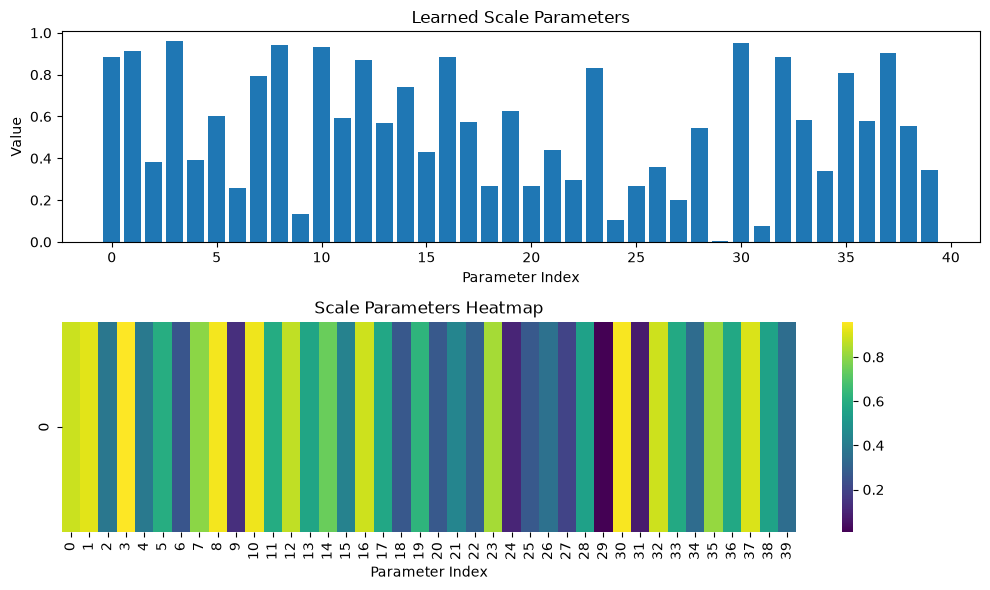

... Model built
 --- Training the quantum NN


Epoch [1/32], Train loss: 1.7491, Val loss: 1.4838, Train acc: 40.3500, Val acc: 47.3333, Best val acc: 47.3333


Epoch [2/32], Train loss: 1.2129, Val loss: 1.0764, Train acc: 59.3833, Val acc: 67.0000, Best val acc: 67.0000


Epoch [3/32], Train loss: 1.0274, Val loss: 1.0129, Train acc: 66.5833, Val acc: 64.1667, Best val acc: 67.0000


Epoch [4/32], Train loss: 0.9324, Val loss: 0.9512, Train acc: 69.9000, Val acc: 68.8333, Best val acc: 68.8333


...

Epoch [16/32], Train loss: 0.6505, Val loss: 0.6490, Train acc: 78.1667, Val acc: 79.1667, Best val acc: 79.6667


Epoch [17/32], Train loss: 0.6311, Val loss: 0.6729, Train acc: 79.1833, Val acc: 76.5000, Best val acc: 79.6667


Epoch [18/32], Train loss: 0.6304, Val loss: 0.6456, Train acc: 79.0000, Val acc: 77.5000, Best val acc: 79.6667


Epoch [19/32], Train loss: 0.6215, Val loss: 0.6132, Train acc: 78.4167, Val acc: 79.5000, Best val acc: 79.6667


KeyboardInterrupt: 

In [14]:
import math
from sklearn import svm
from sklearn.decomposition import PCA


def main():
    set_seed(42)

    batch_size = 64
    size = 28
    pca_comp = 40
    pca_enabled = True
    display = True
    FREQUENCY = 1
    MODES = 10
    epochs = 32
    lr = 0.05
    
    
    # load data
    print("\n Loading dataset...")
    X_train,X_val,y_train,y_val, train_loader,val_loader, INPUT_SIZE, OUTPUT_FEATURES = load_dataset(size, batch_size)
    print(f"... data loader with input size = {INPUT_SIZE}")
    print(f" - training statistics: \n - X_train: {X_train.shape} \n - X_val: {X_val.shape}")

    # Reduce to desired number of components (e.g., 40)
    if pca_enabled:
        print("\n - Extracting PCA components")
        n_components = pca_comp
        pca = PCA(n_components=n_components)

        X_pca = pca.fit_transform(X_train.reshape(X_train.shape[0], size*size))
        X_val_pca = pca.transform(X_val.reshape(X_val.shape[0], size*size))

        X_pca = torch.sigmoid(torch.FloatTensor(X_pca))
        X_val_pca = torch.sigmoid(torch.FloatTensor(X_val_pca))
        print(X_pca.shape)
        print(X_pca[2])

        train_dataset = TensorDataset(X_pca, torch.LongTensor(y_train))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_dataset = TensorDataset(X_val_pca, torch.LongTensor(y_val))
        val_loader = DataLoader(val_dataset, batch_size=batch_size)
        INPUT_SIZE = n_components

    ##################
    ## photonic qNN ##
    ##################
    print("\n - Building the photonic quantum neural network...")
    input_state = [(i + 1) % 2 for i in range(MODES)]
    photons_count = sum(input_state)
    print(f"input state: {input_state}")
    
    Q_Layer = QLayer(photons_count, MODES, INPUT_SIZE*FREQUENCY, scale_type="learned")


    # learnable layer to map to the correct number of classes
    #classification_layer = nn.Linear(in_features=math.comb(MODES + photons_count-1,photons_count), out_features=OUTPUT_FEATURES,
    #                                 bias=True)
    classification_layer = nn.Linear(in_features=math.comb(MODES, photons_count), out_features=OUTPUT_FEATURES, bias=True)
    # input layer that multiplies the input by a learned encoding
    # input_layer = ScaleLayer(INPUT_SIZE*FREQUENCY, scale_type="learned")
    
   # Q_Layer = QLayer(photons_count, MODES, size*FREQUENCY, scale_type="learned")
    if display:
        visualize_scale_parameters(Q_Layer.scaler)
    #nn.init.xavier_uniform_(classification_layer.weight)
    #nn.init.constant_(classification_layer.bias, 0.0)
    # create q_model as nn.Module
    q_model = nn.Sequential(Q_Layer, classification_layer)
    print("... Model built")

    ########################
    ## classical NN (MLP) ##
    ########################
    # 2 layers with ReLU activation
    layer_1 = nn.Linear(in_features=INPUT_SIZE, out_features=32, bias=True)
    layer_2 = nn.Linear(in_features=32, out_features=OUTPUT_FEATURES, bias=True)
    model = nn.Sequential(layer_1, nn.ReLU(), layer_2, nn.Softmax(dim=1))

    #########################
    ## Training the models ##
    #########################

    EPOCHS = epochs
    LR = lr

    print(f" --- Training the quantum NN")

    q_history, best_q_acc = train_model(
        q_model, train_loader, val_loader,
        model_type="classification", num_epochs=EPOCHS, lr=LR, frequency=FREQUENCY,
    )
    q_train_losses, q_val_losses = q_history["train_loss"], q_history["val_loss"]
    q_train_accs, q_val_accs = q_history["train_acc"], q_history["val_acc"]
    if display:
        visualize_scale_parameters(q_model[0].scaler)
        # save qLayer if needed
        #torch.save(q_model[0].state_dict(), 'scale_layer_trained_5.pt')

    # train classical baseline
    print(f" --- Training the classical NN (linear)")
    cl_history, best_cl_acc = train_model(
        model, train_loader, val_loader,
        model_type="classification", num_epochs=EPOCHS, lr=0.01,
    )
    cl_train_losses, cl_val_losses = cl_history["train_loss"], cl_history["val_loss"]
    cl_train_accs, cl_val_accs = cl_history["train_acc"], cl_history["val_acc"]

    ### APPLY SVM ###
    print("--- APPLYING a SVM ---")
    clf = svm.SVC()
    clf.fit(X_train, y_train)
    svm_acc = clf.score(X_val, y_val)
    print(f" -> Validation Accuracy after SVM: {svm_acc}")
    print("--- SVM applied ---")

    print(f" - TRAINING IS DONE - \n - Best validation accuracy for the quantum kernel = {best_q_acc:.4f} (for {count_parameters(q_model)} parameters),"
          f" \n - Best validation accuracy for the linear kernel = {best_cl_acc:.4f} (for {count_parameters(model)} parameters)")

    # display tSNE and confusion matrices if asked in arguments
    if display:
        print("\n - Computing the confusion matrices...")
        display_confusion_matrices(q_model, model, val_loader, device = 'cpu')
        print(" - Computing the tSNE plots")
        display_tsne(nn.Sequential(q_model[0], q_model[1]), model[0], val_loader, MODES, device="cpu")

    # save results
    print("\n - Saving results...")
    result_dict = {"dataset": "mnist",
            "learnable scale": True ,
            "best q ACC": best_q_acc, "best cl ACC": best_cl_acc,
            "q parameters":count_parameters(q_model),"cl parameters":count_parameters(model)}
    save_experiment_results(result_dict)
    print("Results saved !")
    print("\nEXPERIMENT COMPLETE !")


if __name__ == "__main__":
    main()

# Second method

In [ ]:
from merlin import QuantumLayer, ComputationSpace
from merlin.measurement import MeasurementStrategy
import perceval as pcvl
from collections.abc import Iterable

def create_circuit(parameters: Iterable[float] = None, m: int = None) -> pcvl.Circuit:
    if parameters is None:
        parameters = [p for i in range(m * (m - 1) // 2)
                        for p in [pcvl.P(f"phi_{2 * i}"), pcvl.P(f"phi_{2 * i + 1}")]]
    return pcvl.GenericInterferometer(
        m,
        lambda i: (pcvl.BS()
                    .add(0, pcvl.PS(parameters[2 * i]))
                    .add(0, pcvl.BS())
                    .add(0, pcvl.PS(parameters[2 * i + 1])))
    )

In [ ]:
circuit = create_circuit(parameters=None, m=6)

QLayer = QuantumLayer(
    circuit=circuit,
    n_photons=3,
    measurement_strategy=MeasurementStrategy.probs(computation_space=ComputationSpace.DUAL_RAIL),
    trainable_parameters=["phi"]
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from merlin import ComputationSpace, QuantumLayer, MeasurementStrategy, CircuitBuilder

class CNN(nn.Module):
    """Extraction et réduction de dimension d'image classique vers vecteur de caractéristiques."""
    def __init__(self, output_size=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.05),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.05),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.classifier = nn.Linear(128 * 2 * 2, output_size)
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


class QNN(nn.Module):
    """Réseau Hybride CNN + Puce Quantique Merlin (Dual-Rail) + Branche Surrogate."""
    def __init__(self, nb_modes=6, device="cpu", num_classes=10):
        super().__init__()
        self.m = nb_modes
        self.device = device
        
        # 1. Nombre de paramètres d'entrée dynamiques pour la couche d'encodage
        self.num_q_inputs = self._nb_parameters_needed

        # 2. Dimension de sortie réelle du circuit quantique (Dual-Rail : 2^(m/2) états)
        # Pour m = 6 modes -> 2^3 = 8 probabilités de sortie
        self.q_out_dim = 2 ** (self.m // 2)

        # Encodage classique : Projection vers la taille exacte d'entrées de la puce
        self.param_proj = nn.Sequential(
            CNN(output_size=256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, self.num_q_inputs)
        )
        
        # Construction du circuit quantique photonique dans Merlin
        builder = CircuitBuilder(n_modes=self.m)
        builder.add_entangling_layer(trainable=True, model="mzi")
        builder.add_angle_encoding(modes=[i for i in range(self.m)])
        builder.add_entangling_layer(trainable=True, model="mzi")

        self.QLayer = QuantumLayer(
            builder=builder,
            n_photons=3,
            measurement_strategy=MeasurementStrategy.probs(
                computation_space=ComputationSpace.DUAL_RAIL
            ),
        )

        # Modèle de substitution (Surrogate) qui imite la dimension physique (8 probabilités)
        self.surrogate = nn.Sequential(
            nn.Linear(self.num_q_inputs, 256),
            nn.ReLU(), 
            nn.Linear(256, 256),
            nn.Dropout(0.05),
            nn.ReLU(),
            nn.Linear(256, self.q_out_dim),
        )
        
        # Projection finale de classification à partir des 8 probabilités
        self.out_proj = nn.Sequential(
            nn.Linear(self.q_out_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_classes)
        )

    @property
    def _nb_parameters_needed(self) -> int:
        return self.m * (self.m - 1)

    def forward(self, x):
        # 1. Extraction vectorisée pour tout le lot (batch)
        params = self.param_proj(x)

        # 2. Passage vectorisé dans la puce quantique
        measured = self.QLayer(params)
        
        # 3. Isolation du graphe pour la branche optique (non dérivable directement)
        measured = measured.detach()

        # 4. Branche classique de substitution (Surrogate)
        approximated = self.surrogate(params)

        # 5. Projections vers les scores des classes (10)
        out_approx = self.out_proj(approximated)
        out_measured = self.out_proj(measured)
        
        # Calcul de l'erreur d'imitation (MSE)
        surrogate_loss = F.mse_loss(approximated, measured)

        return out_approx, surrogate_loss, out_measured

In [19]:
import pickle
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

# Assurez-vous que load_dataset est bien disponible dans votre module
# from your_dataset_module import load_dataset
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Assurez-vous d'avoir les imports Merlin nécessaires :
# from merlin.datasets import mnist_digits
# from merlin.datasets.transforms import TransformCenter


def load_dataset(size=28, bs=64):
    SIZE = size
    batch_size = bs

    # 1. Chargement des données brutes Merlin / Perceval
    X_train_raw, y_train_raw, _ = mnist_digits.get_data_train_percevalquest()
    X_val_raw, y_val_raw, _ = mnist_digits.get_data_test_percevalquest()

    # 2. Transformation
    transform = TransformCenter(size=SIZE)
    X_train_flat = np.stack([transform(img).numpy() for img in X_train_raw]).astype(
        np.float32
    )
    X_val_flat = np.stack([transform(img).numpy() for img in X_val_raw]).astype(
        np.float32
    )

    y_train = np.asarray(y_train_raw, dtype=np.int64)
    y_val = np.asarray(y_val_raw, dtype=np.int64)

    # 3. Normalisation MinMax
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_val_scaled = scaler.transform(X_val_flat)

    # =========================================================================
    # CORRECTION CRITIQUE ICI :
    # .view(-1, 1, SIZE, SIZE) transforme le vecteur plat [N, 784]
    # en tenseur 4D d'images [N, 1, 28, 28] attendu par le CNN Conv2d.
    # =========================================================================
    train_tensor = (
        torch.from_numpy(X_train_scaled).float().view(-1, 1, SIZE, SIZE)
    )
    val_tensor = torch.from_numpy(X_val_scaled).float().view(-1, 1, SIZE, SIZE)

    train_dataset = TensorDataset(train_tensor, torch.from_numpy(y_train))
    val_dataset = TensorDataset(val_tensor, torch.from_numpy(y_val))

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    INPUT_SIZE = SIZE * SIZE
    OUTPUT_FEATURES = 10

    return (
        X_train_scaled,
        X_val_scaled,
        y_train,
        y_val,
        train_loader,
        val_loader,
        INPUT_SIZE,
        OUTPUT_FEATURES,
    )


def save_training_artifacts(model, history, model_type, save_path):
    """Persist the trained weights and the training history to disk.

    Args:
        model (nn.Module): trained model whose state_dict is saved.
        history (dict): per-epoch metrics returned by train_model.
        model_type (str): label recorded alongside the history (e.g. "hybrid_qnn").
        save_path (str): path to the pickle file; weights are saved next to it
            with a "_model.pth" suffix.

    Returns:
        str: path of the saved model weights file.
    """
    model_state_path = save_path.replace(".pkl", "_model.pth")
    torch.save(model.state_dict(), model_state_path)
    with open(save_path, "wb") as f:
        pickle.dump((history, model_type, model_state_path, str(model)), f)
    print(f"\nSauvegarde terminée : poids dans '{model_state_path}', historique dans '{save_path}'")
    return model_state_path


def plot_training_curves(history, model_type):
    """Plot the loss and accuracy curves recorded by train_model.

    Args:
        history (dict): per-epoch metrics returned by train_model.
        model_type (str): "classification" or "hybrid_qnn"; when "hybrid_qnn" the
            surrogate accuracy curves are shown alongside the measured ones.
    """
    epochs_range = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o", color="#1f77b4")
    plt.plot(epochs_range, history["val_loss"], label="Val Loss", marker="s", color="#ff7f0e", linestyle="--")
    plt.title("Loss evolution", fontsize=13, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)

    plt.subplot(1, 2, 2)
    if model_type == "hybrid_qnn":
        plt.plot(epochs_range, history["train_acc_approx"], label="Train Acc (Surrogate)", color="#2ca02c", alpha=0.4)
        plt.plot(epochs_range, history["val_acc_approx"], label="Val Acc (Surrogate)", color="#2ca02c", linestyle="--", alpha=0.4)

    plt.plot(epochs_range, history["train_acc"], label="Train Acc (Measured)", marker="o", color="#d62728", linewidth=2)
    plt.plot(epochs_range, history["val_acc"], label="Val Acc (Measured)", marker="s", color="#d62728", linestyle="--", linewidth=2)

    plt.title("Accuracy evolution (%)", fontsize=13, fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


--- Exécution sur : cpu ---


Epoch [1/15], Train loss: 1.1990, Val loss: 0.9383, Train acc: 30.0500, Val acc: 26.1667, Best val acc: 26.1667


Epoch [2/15], Train loss: 0.7693, Val loss: 0.8473, Train acc: 50.3333, Val acc: 34.0000, Best val acc: 34.0000


Epoch [3/15], Train loss: 0.7146, Val loss: 0.6789, Train acc: 54.3333, Val acc: 60.3333, Best val acc: 60.3333


Epoch [4/15], Train loss: 0.6318, Val loss: 0.6180, Train acc: 69.5000, Val acc: 75.1667, Best val acc: 75.1667


...

Epoch [11/15], Train loss: 0.4763, Val loss: 0.4857, Train acc: 87.6333, Val acc: 93.5000, Best val acc: 93.5000


Epoch [12/15], Train loss: 0.4701, Val loss: 0.4823, Train acc: 89.4667, Val acc: 92.5000, Best val acc: 93.5000


Epoch [13/15], Train loss: 0.4698, Val loss: 0.4800, Train acc: 89.1667, Val acc: 93.5000, Best val acc: 93.5000


Epoch [14/15], Train loss: 0.4686, Val loss: 0.4769, Train acc: 88.4500, Val acc: 94.3333, Best val acc: 94.3333


Epoch [15/15], Train loss: 0.4660, Val loss: 0.4779, Train acc: 89.3000, Val acc: 93.3333, Best val acc: 94.3333

Sauvegarde terminée : poids dans 'mon_qnn_model.pth', historique dans 'mon_qnn.pkl'


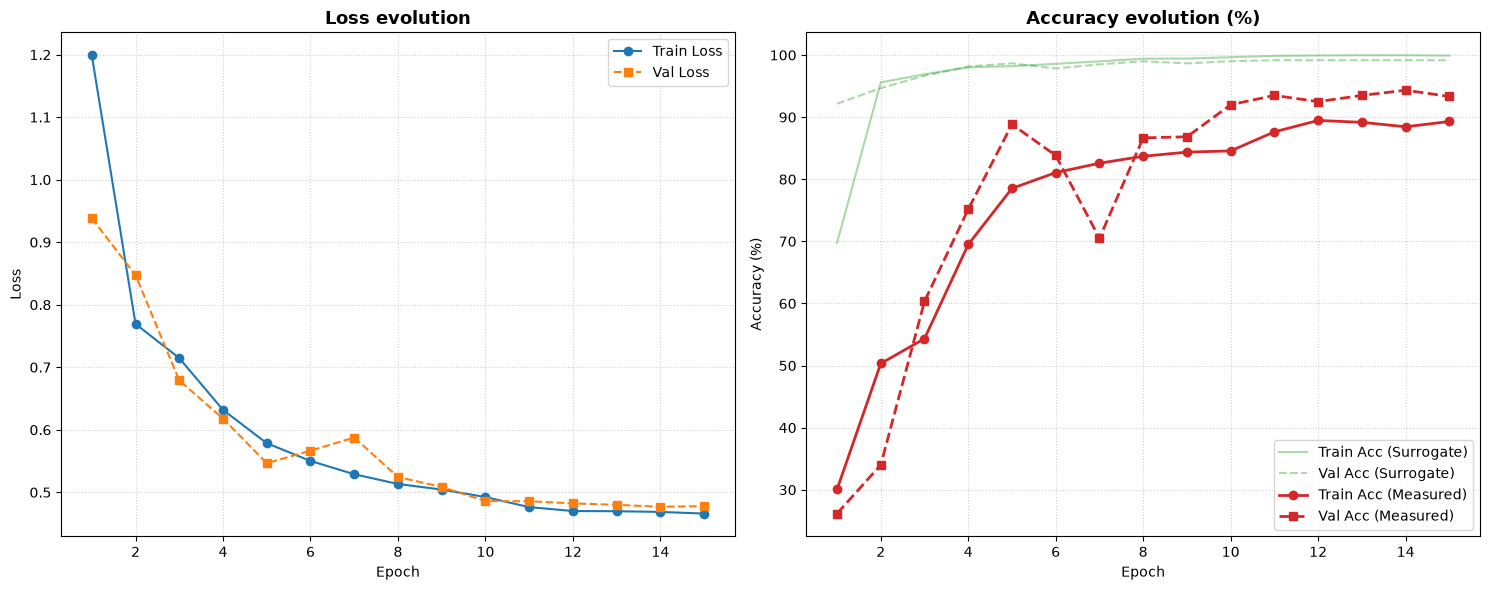

In [ ]:
if __name__ == "__main__":
    # 1. Détection du GPU ou CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"--- Exécution sur : {device} ---")

    # 2. Instanciation du modèle avec 6 modes optiques
    model = QNN(nb_modes=6, device=device, num_classes=10)
    model = model.to(device)

    # 3. Chargement des données
    _, _, _, _, train_loader, val_loader, _, _ = load_dataset(size=28, bs=64)

    # 4. Lancement de la procédure d'apprentissage
    history, best_val_acc = train_model(
        model, train_loader, val_loader,
        model_type="hybrid_qnn",
        num_epochs=15, lr=0.001, weight_decay=1e-4, label_smoothing=0.1,
        device=device, save_path="mon_qnn.pkl",
    )
    plot_training_curves(history, model_type="hybrid_qnn")


# Third Method : Lancelot

In [15]:
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt

# modes=6 in Quantum_Model; UA's dilation doubles a (EFF_IMG_SIZE, EFF_IMG_SIZE) contraction,
# so EFF_IMG_SIZE must be modes // 2 for the resulting unitary to fit the circuit's mode count.
EFF_IMG_SIZE = 3


def toHamiltonian(x):
    H = 0.5*(x[:, :, 0] + x[:, :, 0].T)
    return H


def plot_hamiltonian(x):
    L = [x, toHamiltonian(x)]
    labels = ['Matrix', 'Hamiltonian']
    fig, axes = plt.subplots(1, 2, figsize=(5, 5))
    for i in range(2):
        axes[i].imshow(L[i], cmap='gray_r')
        axes[i].set_title(labels[i])
        axes[i].axis('off')
    plt.show()


def U(x: np.ndarray, t: float) -> np.ndarray:
    """Compute the unitary operator associated with the Hamiltonian x and time t"""
    H = toHamiltonian(x)
    return linalg.expm(-1j*H*t)


def UA(x: np.ndarray) -> np.ndarray:
    """Compute the unitary operator using unitary dilation"""
    x = x[:, :, 0]
    x = x / (1.7 * np.linalg.norm(x, ord=2))
    identity = np.eye(EFF_IMG_SIZE)
    B = np.block([
        [x, linalg.sqrtm(identity - x @ x.T)],
        [linalg.sqrtm(identity - x.T @ x), -x.T]
    ])
    return B


In [64]:
import math
import itertools
import numpy as np
import scipy.linalg as la
import torch
from torch import nn
import perceval as pcvl
from perceval.backends import BackendFactory

class ExactUDENNModel(nn.Module):
    def __init__(self, L=6, num_classes=10, n=3, photons=3):
        super().__init__()
        self.n = n
        self.modes = 2 * n
        self.photons = photons
        self.L = L
        
        # Réduction de l'image
        pool_kernel = max(1, 28 // self.n)
        self.pool = nn.MaxPool2d(kernel_size=pool_kernel, stride=pool_kernel)
        
        # Poids PyTorch (SPSA)
        num_bricks = self.L * (self.modes // 2)
        self.phi_tl = nn.Parameter(torch.randn(num_bricks))
        self.phi_bl = nn.Parameter(torch.randn(num_bricks))
        self.theta = nn.Parameter(torch.randn(num_bricks))
        self.phi_tr = nn.Parameter(torch.randn(num_bricks))
        
        # --- NOUVEAUTÉ : Paramètres dynamiques Perceval ---
        self.pcvl_params = {
            "phi_tl": [pcvl.P(f"phi_tl_{i}") for i in range(num_bricks)],
            "phi_bl": [pcvl.P(f"phi_bl_{i}") for i in range(num_bricks)],
            "theta": [pcvl.P(f"theta_{i}") for i in range(num_bricks)],
            "phi_tr": [pcvl.P(f"phi_tr_{i}") for i in range(num_bricks)],
        }
        
        # --- NOUVEAUTÉ : Pré-construction des sous-circuits ---
        self.bs_row = pcvl.Circuit(self.modes)
        for i in range(0, self.modes - 1, 2):
            self.bs_row.add(i, pcvl.BS())
            
        self.brickwork_layers = []
        brick_idx = 0
        for layer in range(self.L):
            circ = pcvl.Circuit(self.modes)
            for i in range(layer % 2, self.modes - 1, 2):
                circ.add(i, pcvl.PS(self.pcvl_params["phi_tl"][brick_idx]))
                circ.add(i+1, pcvl.PS(self.pcvl_params["phi_bl"][brick_idx]))
                circ.add(i, pcvl.BS(theta=self.pcvl_params["theta"][brick_idx]))
                circ.add(i, pcvl.PS(self.pcvl_params["phi_tr"][brick_idx]))
                brick_idx += 1
            self.brickwork_layers.append(circ)
        
        self.simulator = BackendFactory.get_backend("SLOS")
        
        # État d'entrée
        in_state = [0] * self.modes
        photons_placed = 0
        for i in range(0, self.n, 2):
            if photons_placed < self.photons:
                in_state[i] = 1
                photons_placed += 1
        self.input_state = pcvl.BasicState(in_state)
        
        # Génération des états de post-sélection (moitié supérieure et inférieure)
        self.expected_states = []
        for positions in itertools.combinations(range(self.n), self.photons):
            state = [0] * self.modes
            for pos in positions: state[pos] = 1
            self.expected_states.append(pcvl.BasicState(state))
            
        for positions in itertools.combinations(range(self.n, self.modes), self.photons):
            state = [0] * self.modes
            for pos in positions: state[pos] = 1
            self.expected_states.append(pcvl.BasicState(state))
            
        self.readout = nn.Linear(len(self.expected_states), num_classes)

    def _unitary_dilation(self, A_tensor):
        # 1. Forcer la conversion en float64 (double précision) pour limiter les erreurs
        A = A_tensor.detach().cpu().numpy().astype(np.float64)
        
        # 2. Normalisation stricte
        norm_A = np.linalg.norm(A, ord=2)
        if norm_A > 0:
            # On divise par une valeur légèrement supérieure pour assurer ||A|| < 1
            A = A / (norm_A + 1e-6)
            
        identity = np.eye(self.n, dtype=np.float64)
        
        # 3. Calcul de la dilatation en ignorant les minuscules parties imaginaires (.real)
        # Puisque les images d'entrée sont réelles, la racine doit l'être aussi.
        top_right = la.sqrtm(identity - A @ A.T).real
        bottom_left = la.sqrtm(identity - A.T @ A).real
        bottom_right = -A.T
        
        Ua_approx = np.block([[A, top_right], [bottom_left, bottom_right]])
        
        # 4. PROJECTION SVD : Restauration stricte de l'unitarité pour satisfaire Perceval
        U, _, Vh = np.linalg.svd(Ua_approx)
        Ua_strict = U @ Vh
        
        return Ua_strict

    def forward(self, x):
        # Synchronisation immédiate des valeurs SPSA vers Perceval (sans recréer de portes)
        with torch.no_grad():
            for i in range(len(self.phi_tl)):
                self.pcvl_params["phi_tl"][i].set_value(float(self.phi_tl[i].item()))
                self.pcvl_params["phi_bl"][i].set_value(float(self.phi_bl[i].item()))
                self.pcvl_params["theta"][i].set_value(float(self.theta[i].item()))
                self.pcvl_params["phi_tr"][i].set_value(float(self.phi_tr[i].item()))

        batch_size = x.size(0)
        x_pooled = self.pool(x).squeeze(1)
        batch_probs = []
        
        for b in range(batch_size):
            Ua = self._unitary_dilation(x_pooled[b])
            
            # Assemblage ultra-rapide des blocs pré-compilés
            circuit = pcvl.Circuit(self.modes)
            circuit.add(0, self.bs_row, merge=True)
            
            for layer in range(self.L):
                circuit.add(0, pcvl.Unitary(pcvl.Matrix(Ua)))
                circuit.add(0, self.brickwork_layers[layer], merge=True)
                
            self.simulator.set_circuit(circuit)
            self.simulator.set_input_state(self.input_state)
            probs = self.simulator.prob_distribution()
            
            # Filtrage rapide
            state_probs = [probs.get(state, 0.0) for state in self.expected_states]
            
            total_prob = sum(state_probs) + 1e-9
            state_probs = [p / total_prob for p in state_probs]
            
            batch_probs.append(torch.tensor(state_probs, device=x.device, dtype=torch.float32))
            
        quantum_out = torch.stack(batch_probs)
        return self.readout(quantum_out)



# import math
# import numpy as np
# import torch
# from torch import nn
# import torch.nn.functional as F
# import perceval as pcvl
# from merlin import QuantumLayer, ComputationSpace
# from merlin.measurement import MeasurementStrategy

# # Assurez-vous que U() et UA() de votre fichier util.py sont importées
# # from util import U, UA, EFF_IMG_SIZE

# class UnifiedOpticalModel(nn.Module):
#     """
#     Modèle unique intégrant la définition du circuit optique, la couche quantique
#     et une simple couche de classification linéaire (sans ClassicalHead).
#     """
#     def __init__(self, unitary_mode="hamiltonian", t=1.0, L=2, num_classes=10, seed=None, modes=6, photons=3):
#         super().__init__()
        
#         # Paramètres fixes de l'architecture
#         self.modes = modes
#         self.photons = photons
#         self.L = L
#         self.input_size = self.L * (self.modes // 2)
        
#         # 1. Génération de la matrice unitaire centrale (fixe)
#         rng = np.random.default_rng(seed)
#         if unitary_mode == "dilation":
#             x_ref = rng.standard_normal((3, 3, 1)) # EFF_IMG_SIZE = 3
#             self.mid_unitary = UA(x_ref)
#         else:
#             x_ref = rng.standard_normal((self.modes, self.modes, 1))
#             self.mid_unitary = U(x_ref, t)
            
#         # 2. Construction de la couche quantique
#         self.quantum_layer = self._build_quantum_layer()
        
#         # 3. Réduction de l'image pour l'encodage quantique (corrige l'erreur Input dimension)
#         self.pool = nn.AdaptiveAvgPool2d((1, self.input_size))
        
#         # 4. Couche de classification finale (purement linéaire)
#         n_probs = math.comb(self.modes, self.photons)
#         self.readout = nn.Linear(n_probs, num_classes)

#     # --- Fonction 1 : Définition de la cellule de base ---
#     def _lancelot_cell(self, layer_idx, brick_idx):
#         cell = pcvl.Circuit(2)
#         cell.add(0, pcvl.PS(pcvl.P(f"phi_tl_{layer_idx}_{brick_idx}")))
#         cell.add(1, pcvl.PS(pcvl.P(f"phi_bl_{layer_idx}_{brick_idx}")))
#         cell.add(0, pcvl.BS(theta=pcvl.P(f"theta_{layer_idx}_{brick_idx}")))
#         cell.add(0, pcvl.PS(pcvl.P(f"phi_tr_{layer_idx}_{brick_idx}")))
#         return cell

#     # --- Fonction 2 : Construction du circuit global ---
#     def _build_lancelot_circuit(self):
#         m = self.modes
#         half = m // 2
#         circuit = pcvl.Circuit(m)

#         def add_layer(i):
#             encoding_modes = range(0, half) if i % 2 == 0 else range(half, m)
#             encoder = pcvl.Circuit(m)
#             # Les données sont encodées ici via les paramètres "px"
#             for mode in encoding_modes:
#                 encoder.add(mode, pcvl.PS(pcvl.P(f"px_{i}_{mode}")))
#             circuit.add(0, encoder, merge=True)

#             block = pcvl.GenericInterferometer(
#                 m,
#                 lambda brick_idx, i=i: self._lancelot_cell(i, brick_idx),
#                 shape=pcvl.InterferometerShape.RECTANGLE,
#             )
#             circuit.add(0, block, merge=True)

#         first_half = self.L // 2
#         for i in range(first_half):
#             add_layer(i)

#         # Insertion de la matrice unitaire au centre
#         circuit.add(0, pcvl.Unitary(pcvl.Matrix(self.mid_unitary)), merge=True)

#         for i in range(first_half, self.L):
#             add_layer(i)

#         return circuit

#     # --- Fonction 3 : Construction de la couche Merlin ---
#     def _build_quantum_layer(self):
#         circuit = self._build_lancelot_circuit()
#         input_state = [(i + 1) % 2 for i in range(self.modes)]

#         return QuantumLayer(
#             input_size=self.input_size,
#             circuit=circuit,
#             input_state=input_state,
#             measurement_strategy=MeasurementStrategy.probs(
#                 computation_space=ComputationSpace.UNBUNCHED
#             ),
#             input_parameters=["px"],
#             trainable_parameters=["phi", "theta"],
#         )

#     def forward(self, x):
#         # 1. Préparation des données (gestion dynamique 2D/4D pour éviter le ValueError)
#         if x.dim() == 2:
#             side = int(math.sqrt(x.shape[1]))
#             x = x.view(x.shape[0], 1, side, side)
            
#         features = self.pool(x).flatten(1)  # Devient un vecteur de taille 'input_size'
        
#         # 2. Passage dans le circuit quantique (encodage par 'px')
#         probs = self.quantum_layer(features)
        
#         # 3. Classification linéaire simple
#         return self.readout(probs)

In [49]:
from tqdm.auto import tqdm


class SPSAOptimizer:
    """Zeroth-order SPSA optimizer for one parameter group (e.g. the optical bs/phase params).

    Unlike a torch.optim.Optimizer, step() takes a `loss_fn` callable (no args, returns a
    scalar) and estimates the gradient from two forward-only loss evaluations at randomly
    perturbed parameter values -- the same finite-difference update as `train_SPSA`. Managed
    parameters are switched to requires_grad=False so autograd never touches them: SPSA owns
    their updates exclusively, and downstream (classical) layers still backprop normally since
    only their own weights need to require grad for that.
    """

    def __init__(self, params, a=0.05, c=0.05, alpha=0.602, gamma=0.101):
        self.params = list(params)
        for p in self.params:
            p.requires_grad_(False)
        self.a, self.c, self.alpha, self.gamma = a, c, alpha, gamma
        self.k = 0

    @torch.no_grad()
    def step(self, loss_fn):
        """Perturb +/- ck*delta, evaluate loss_fn() at each point, and apply the SPSA update."""
        self.k += 1
        ak = self.a / self.k**self.alpha
        ck = self.c / self.k**self.gamma

        # Rademacher (+-1) perturbation, one draw shared by the plus/minus evaluations
        deltas = [torch.randint(0, 2, p.shape, device=p.device, dtype=p.dtype) * 2 - 1 for p in self.params]

        for p, d in zip(self.params, deltas):
            p.add_(ck * d)
        loss_plus = loss_fn()

        for p, d in zip(self.params, deltas):
            p.add_(-2 * ck * d)
        loss_minus = loss_fn()

        for p, d in zip(self.params, deltas):
            grad_estimate = (loss_plus - loss_minus) / (2 * ck * d)
            p.add_(ck * d - ak * grad_estimate)  # undo the "-ck*d" step, then apply -ak*grad_estimate


def train(
    model,
    optimizers,
    criterion,
    train_loader,
    val_loader,
    num_epochs=15,
    device="cpu",
):
    """Universal training loop for the classical-only, optical-only, and hybrid models.

    `optimizers` is a dict; only the provided keys are optimized. Each value is either a
    torch.optim.Optimizer (fast, gradient-based step -- e.g. Adam on a classical head) or an
    SPSAOptimizer (slow, zeroth-order step -- e.g. on the optical bs/phase parameters).
    Dispatch is by optimizer type, not by key name or model architecture, so the exact same
    loop trains a classical-only model ({"classical": adam}), a purely optical model
    ({"optical": spsa}), or the hybrid model ({"classical": adam, "optical": spsa}).
    """
    model = model.to(device)
    grad_optims = [opt for opt in optimizers.values() if isinstance(opt, torch.optim.Optimizer)]
    spsa_optims = [opt for opt in optimizers.values() if isinstance(opt, SPSAOptimizer)]

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [train]", leave=False):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            # 1. fast gradient-based step, only for parameter groups backed by a torch optimizer
            if grad_optims:
                for opt in grad_optims:
                    opt.zero_grad()
                loss.backward()
                for opt in grad_optims:
                    opt.step()

            # 2. slow zeroth-order SPSA step(s), re-evaluating the loss without autograd
            if spsa_optims:
                def batch_loss():
                    with torch.no_grad():
                        return criterion(model(batch_X), batch_y).item()

                for opt in spsa_optims:
                    opt.step(batch_loss)
                with torch.no_grad():
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)

            total_loss += loss.item()
            total += batch_y.size(0)
            correct += (outputs.argmax(dim=-1) == batch_y).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total

        model.eval()
        val_total_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch_X, batch_y in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [val]", leave=False):
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_total_loss += loss.item()
                val_total += batch_y.size(0)
                val_correct += (outputs.argmax(dim=-1) == batch_y).sum().item()

        val_loss = val_total_loss / len(val_loader)
        val_acc = 100 * val_correct / val_total
        best_val_acc = max(best_val_acc, val_acc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}], Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}, "
            f"Train acc: {train_acc:.2f}%, Val acc: {val_acc:.2f}%, Best val acc: {best_val_acc:.2f}%"
        )

    return history, best_val_acc


In [51]:
# class ImageToFeatures(nn.Module):
#     """Pools a (N,1,H,W) image batch to the flat vector the quantum encoding layer expects."""
#     def __init__(self, out_features):
#         super().__init__()
#         self.pool = nn.AdaptiveAvgPool2d((1, out_features))

#     def forward(self, x):
#         return self.pool(x).flatten(1)


# if __name__ == "__main__":
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#     # 1. data: load_dataset() is this notebook's loader (the reference notebook's load_data()
#     # is a separate TensorFlow/CSV pipeline that isn't part of this codebase)
#     _, _, _, _, train_loader, val_loader, _, _ = load_dataset(size=28, bs=64)

#     # 2. instantiate the three candidate models
#     classical_model = ClassicalModel().to(device)

#     optical_core = OpticalModel(unitary_mode="hamiltonian", t=1.0, L=6)
#     optical_model = nn.Sequential(ImageToFeatures(optical_core.input_size), optical_core).to(device)

#     hybrid_core = Quantum_Model(unitary_mode="hamiltonian", t=1.0, L=6)
#     hybrid_model = nn.Sequential(ImageToFeatures(hybrid_core.input_size), hybrid_core).to(device)

#     criterion = nn.CrossEntropyLoss()

#     # 3. train the hybrid model to validate the full pipeline: fast Adam for the CNN head,
#     # slow SPSA for the optical bs/phase parameters. train() only ever sees these two keys,
#     # so the same call would work with just one of them for the other two models, e.g.:
#     #   train(classical_model, {"classical": torch.optim.Adam(classical_model.parameters(), lr=1e-3)}, ...)
#     #   train(optical_model, {"optical": SPSAOptimizer(optical_core.parameters())}, ...)
#     optimizers = {
#         "classical": torch.optim.Adam(hybrid_core.classical_head.parameters(), lr=1e-3),
#         "optical": SPSAOptimizer(hybrid_core.quantum_layer.parameters()),
#     }

#     history, best_val_acc = train(
#         hybrid_model, optimizers, criterion, train_loader, val_loader,
#         num_epochs=15, device=device,
#     )


if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Chargement de vos données
    _, _, _, _, train_loader, val_loader, _, _ = load_dataset(size=28, bs=64)

    # 1. Instanciation de votre modèle unique
    model = UnifiedOpticalModel(unitary_mode="hamiltonian", t=1.0, L=6, num_classes=10, modes=6, photons=3).to(device)
    
    criterion = nn.CrossEntropyLoss()

    # 2. Configuration des optimiseurs
    # "classical" pointe désormais vers la simple couche linéaire (readout)
    optimizers = {
        "classical": torch.optim.Adam(model.readout.parameters(), lr=1e-2),
        "optical": SPSAOptimizer(model.quantum_layer.parameters()),
    }

    # 3. Lancement de l'entraînement
    history, best_val_acc = train(
        model, optimizers, criterion, train_loader, val_loader,
        num_epochs=40, device=device,
    )

Epoch [1/40], Train loss: 2.2911, Val loss: 2.2859, Train acc: 12.32%, Val acc: 12.83%, Best val acc: 12.83%


Epoch [2/40], Train loss: 2.2630, Val loss: 2.2638, Train acc: 17.75%, Val acc: 20.83%, Best val acc: 20.83%


Epoch [3/40], Train loss: 2.2365, Val loss: 2.2383, Train acc: 22.47%, Val acc: 24.83%, Best val acc: 24.83%


Epoch [4/40], Train loss: 2.2066, Val loss: 2.2164, Train acc: 26.35%, Val acc: 24.83%, Best val acc: 24.83%


Epoch [5/40], Train loss: 2.1777, Val loss: 2.1935, Train acc: 28.27%, Val acc: 26.33%, Best val acc: 26.33%


...

Epoch [36/40], Train loss: 1.8809, Val loss: 1.9633, Train acc: 35.53%, Val acc: 32.33%, Best val acc: 33.67%


Epoch [37/40], Train loss: 1.8911, Val loss: 1.9736, Train acc: 35.20%, Val acc: 30.83%, Best val acc: 33.67%


Epoch [38/40], Train loss: 1.8934, Val loss: 1.9779, Train acc: 35.58%, Val acc: 31.33%, Best val acc: 33.67%


Epoch [39/40], Train loss: 1.9050, Val loss: 1.9809, Train acc: 35.68%, Val acc: 30.33%, Best val acc: 33.67%


Epoch [40/40], Train loss: 1.9150, Val loss: 1.9950, Train acc: 34.95%, Val acc: 30.50%, Best val acc: 33.67%


In [65]:
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Chargement de vos données
    _, _, _, _, train_loader, val_loader, _, _ = load_dataset(size=28, bs=64)

    # 1. Instanciation de votre modèle unique
    model = ExactUDENNModel(L=6, num_classes=10, n=3, photons=3).to(device)
    
    criterion = nn.CrossEntropyLoss()

    # 2. Récupération explicite des paramètres optiques
    optical_parameters = [
        model.phi_tl,
        model.phi_bl,
        model.theta,
        model.phi_tr
    ]

    # 3. Configuration des optimiseurs
    optimizers = {
        "classical": torch.optim.Adam(model.readout.parameters(), lr=1e-2),
        "optical": SPSAOptimizer(optical_parameters),
    }

    # 4. Lancement de l'entraînement
    history, best_val_acc = train(
        model, optimizers, criterion, train_loader, val_loader,
        num_epochs=40, device=device,
    )

Epoch [1/40], Train loss: 2.3137, Val loss: 2.3046, Train acc: 11.03%, Val acc: 12.33%, Best val acc: 12.33%


Epoch [2/40], Train loss: 2.2999, Val loss: 2.3029, Train acc: 12.08%, Val acc: 12.33%, Best val acc: 12.33%


Epoch [3/40], Train loss: 2.3000, Val loss: 2.3047, Train acc: 12.08%, Val acc: 12.33%, Best val acc: 12.33%


Epoch [4/40], Train loss: 2.3002, Val loss: 2.3039, Train acc: 12.08%, Val acc: 12.33%, Best val acc: 12.33%


Epoch [5/40], Train loss: 2.2999, Val loss: 2.3041, Train acc: 12.08%, Val acc: 12.33%, Best val acc: 12.33%


KeyboardInterrupt: 